# 01 - Khám phá dữ liệu

**Giai đoạn trong pipeline:** Vấn đề -> **Dữ liệu / Khám phá -> Tiền xử lý / Biến đổi** -> Chia tập Train/Val/Test -> Mô hình cơ sở -> ...

Notebook này trả lời một câu hỏi duy nhất: **dữ liệu trông như thế nào trước khi mô hình
"nhìn thấy" nó?** Trước khi huấn luyện, chúng ta khám phá và hiểu rõ FashionMNIST:

1. Tổng quan bộ dữ liệu (kích thước, số lớp, kích thước ảnh, khoảng giá trị gốc)
2. Phân bố lớp (cân bằng hay mất cân bằng)
3. Mẫu ảnh gốc tiêu biểu (mỗi lớp một ảnh)
4. Kiểm tra dữ liệu (kích thước, tính hợp lệ của nhãn, kiểm tra batch, kiểm tra rò rỉ dữ liệu)
5. Giải thích pipeline tiền xử lý (RAW -> ToTensor -> Normalize -> đầu vào mô hình)
6. Trực quan hóa trước / sau khi biến đổi
7. Chiến lược chia tập train / validation / test
8. Khả năng tái lập (reproducibility)
9. Tăng cường dữ liệu (chỉ mang tính minh họa - không dùng trong các lần chạy chính thức)

Không có mô hình nào được huấn luyện ở đây - notebook này chỉ khám phá dữ liệu, và mọi
con số/biểu đồ bên dưới đều được tính trực tiếp từ bộ dữ liệu thật và split đã lưu thật,
không phải gõ tay.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torchvision import datasets, transforms

from src.dataset import (
    CLASS_NAMES,
    DATA_DIR,
    FASHION_MNIST_MEAN,
    FASHION_MNIST_STD,
    SPLITS_DIR,
    build_transforms,
    get_dataloaders,
)
from src.visualization import plot_class_distribution, plot_sample_images


## 1. Tổng quan bộ dữ liệu

FashionMNIST là bộ dữ liệu thay thế trực tiếp cho MNIST: 70,000 ảnh xám của các loại
trang phục (60,000 ảnh train chính thức + 10,000 ảnh test chính thức), 10 lớp cân bằng,
kích thước 28x28 pixel, 1 kênh màu.


In [2]:
raw_train = datasets.FashionMNIST(root=str(DATA_DIR), train=True, download=True)
raw_test = datasets.FashionMNIST(root=str(DATA_DIR), train=False, download=True)

sample_img, sample_label = raw_train[0]
sample_array = np.array(sample_img)

print("Tên bộ dữ liệu: FashionMNIST")
print(f"Số lượng mẫu huấn luyện: {len(raw_train)}")
print(f"Số lượng mẫu kiểm tra:   {len(raw_test)}")
print(f"Số lượng lớp: {len(CLASS_NAMES)}")
print(f"Tên các lớp: {CLASS_NAMES}")
print(f"Kích thước ảnh (H, W): {sample_array.shape}")
print("Số kênh màu: 1 (ảnh xám)")
print(f"Kiểu dữ liệu pixel gốc: {sample_array.dtype}, khoảng giá trị: [{sample_array.min()}, {sample_array.max()}]")
print(f"Kiểu dữ liệu nhãn: {type(sample_label).__name__}, ví dụ nhãn: {sample_label} ({CLASS_NAMES[sample_label]})")


Tên bộ dữ liệu: FashionMNIST
Số lượng mẫu huấn luyện: 60000
Số lượng mẫu kiểm tra:   10000
Số lượng lớp: 10
Tên các lớp: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Kích thước ảnh (H, W): (28, 28)
Số kênh màu: 1 (ảnh xám)
Kiểu dữ liệu pixel gốc: uint8, khoảng giá trị: [0, 255]
Kiểu dữ liệu nhãn: int, ví dụ nhãn: 9 (Ankle boot)


**Nhận xét:** FashionMNIST cung cấp 60,000 ảnh huấn luyện và 10,000 ảnh kiểm tra, mỗi ảnh
có kích thước 28x28, một kênh màu (ảnh xám), giá trị pixel được lưu dưới dạng `uint8`
trong khoảng `[0, 255]`. Nhãn là số nguyên trong khoảng `[0, 9]`, mỗi giá trị ứng với một
lớp. Đây là bộ dữ liệu chuẩn, đã được làm sạch sẵn - chúng ta không cần lo về giá trị
thiếu, file lỗi, hay phải làm sạch dữ liệu thủ công.


## 2. Phân bố lớp

Đếm số lượng mẫu của từng lớp trong cả tập huấn luyện và tập kiểm tra, đồng thời kiểm tra
xem bộ dữ liệu có cân bằng hay mất cân bằng.


In [3]:
train_labels = np.array(raw_train.targets)
test_labels = np.array(raw_test.targets)

train_counts = np.bincount(train_labels, minlength=len(CLASS_NAMES))
test_counts = np.bincount(test_labels, minlength=len(CLASS_NAMES))

counts_df = pd.DataFrame({
    "ten_lop": CLASS_NAMES,
    "so_luong_train": train_counts,
    "so_luong_test": test_counts,
})
counts_df


,ten_lop,so_luong_train,so_luong_test
0,T-shirt/top,6000,1000
1,Trouser,6000,1000
2,Pullover,6000,1000
3,Dress,6000,1000
4,Coat,6000,1000
5,Sandal,6000,1000
6,Shirt,6000,1000
7,Sneaker,6000,1000
8,Bag,6000,1000
9,Ankle boot,6000,1000


/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_6639/1039603307.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_6639/1039603307.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


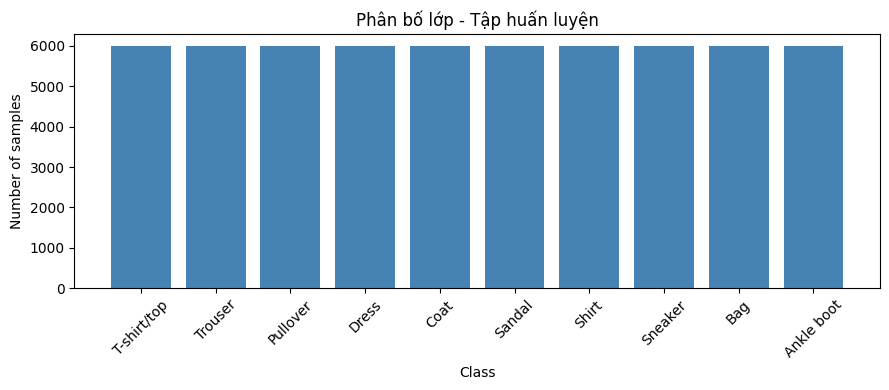

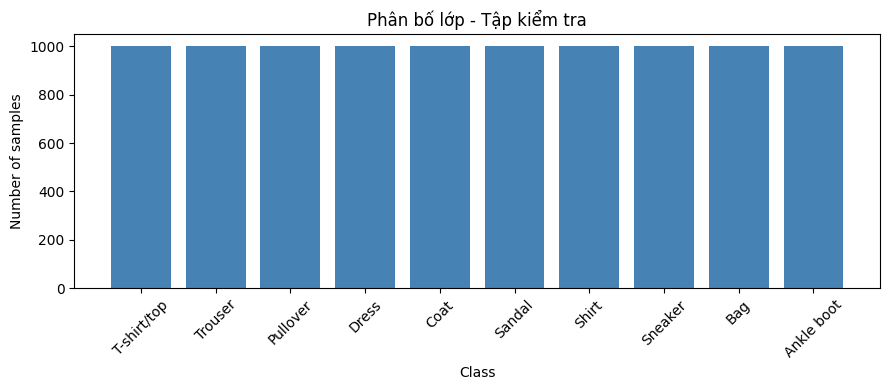

In [4]:
fig = plot_class_distribution(train_labels, CLASS_NAMES, title="Phân bố lớp - Tập huấn luyện")
fig.show()

fig = plot_class_distribution(test_labels, CLASS_NAMES, title="Phân bố lớp - Tập kiểm tra")
fig.show()


**Nhận xét:** mỗi lớp có chính xác 6,000 ảnh huấn luyện và 1,000 ảnh kiểm tra - bộ dữ liệu
**cân bằng hoàn toàn**. Điều này có nghĩa là độ chính xác (accuracy) đơn thuần là một
thước đo có ý nghĩa ở đây, và chúng ta không cần gán trọng số theo lớp, oversampling,
hay điều chỉnh hàm mất mát theo tầng lớp (stratified loss).


## 3. Mẫu ảnh gốc tiêu biểu (mỗi lớp một ảnh)

Một lưới ảnh gồm đúng một ảnh cho mỗi lớp trong 10 lớp, để mọi lớp đều được thể hiện
trực quan ít nhất một lần.


/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_6639/310840097.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


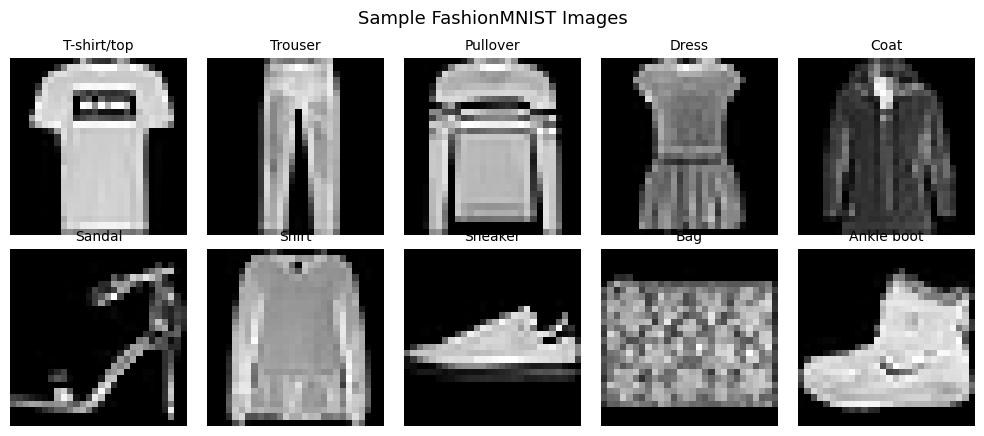

In [5]:
class_to_index = {}
for idx in range(len(raw_train)):
    label = int(raw_train.targets[idx])
    if label not in class_to_index:
        class_to_index[label] = idx
    if len(class_to_index) == len(CLASS_NAMES):
        break

ordered_indices = [class_to_index[c] for c in range(len(CLASS_NAMES))]
grid_images = np.stack([np.array(raw_train[i][0]) for i in ordered_indices])
grid_labels = np.array([raw_train[i][1] for i in ordered_indices])

fig = plot_sample_images(grid_images[:, None, :, :], grid_labels, CLASS_NAMES, n=10)
fig.show()


**Nhận xét:** lưới ảnh trên cho thấy một ảnh đại diện cho mỗi lớp (lớp 0 - T-shirt/top
đến lớp 9 - Ankle boot). Về mặt hình ảnh, một số lớp đã trông khá giống nhau về hình dáng
(Shirt so với T-shirt/top, Pullover, Coat), điều này báo trước một số nhầm lẫn mà chúng ta
sẽ định lượng cụ thể sau trong notebook phân tích lỗi.


## 4. Kiểm tra dữ liệu

Trước khi tin tưởng vào bất kỳ DataLoader nào, chúng ta cần kiểm tra rõ ràng: kích thước
ảnh, tính hợp lệ của nhãn, kích thước tensor sau khi biến đổi, kích thước mini-batch, và
đảm bảo tiền xử lý không làm thay đổi nhãn hay gây rò rỉ dữ liệu (leakage) giữa các tập
train/validation/test.


In [6]:
train_transform, eval_transform = build_transforms(augmentation=False)

raw_pil, raw_label = raw_train[0]
transformed_tensor = eval_transform(raw_pil)

print("--- Kiểm tra trên một mẫu đơn lẻ ---")
print(f"Kích thước ảnh gốc (PIL, W x H): {raw_pil.size}")
print(f"Nhãn gốc: {raw_label} (khoảng hợp lệ: 0-{len(CLASS_NAMES) - 1})")
print(f"Kích thước tensor sau biến đổi: {tuple(transformed_tensor.shape)}  (C, H, W)")
print(f"Kiểu dữ liệu tensor: {transformed_tensor.dtype}")
print(f"Khoảng giá trị tensor sau ToTensor+Normalize: [{transformed_tensor.min():.3f}, {transformed_tensor.max():.3f}]")

# Tiền xử lý không được phép làm thay đổi nhãn - đọc lại nhãn sau khi dựng tensor để xác nhận điều này.
assert raw_train[0][1] == raw_label, "Tiền xử lý không được làm thay đổi nhãn"
assert 0 <= raw_label < len(CLASS_NAMES), "Nhãn nằm ngoài khoảng hợp lệ"
print("Đã xác nhận: nhãn không bị ảnh hưởng bởi tiền xử lý.")


--- Kiểm tra trên một mẫu đơn lẻ ---
Kích thước ảnh gốc (PIL, W x H): (28, 28)
Nhãn gốc: 9 (khoảng hợp lệ: 0-9)
Kích thước tensor sau biến đổi: (1, 28, 28)  (C, H, W)
Kiểu dữ liệu tensor: torch.float32
Khoảng giá trị tensor sau ToTensor+Normalize: [-0.810, 2.023]
Đã xác nhận: nhãn không bị ảnh hưởng bởi tiền xử lý.


In [7]:
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=64, validation_ratio=0.1, augmentation=False, seed=42
)

images, labels = next(iter(train_loader))
print("--- Kiểm tra mini-batch (train_loader) ---")
print(f"Kích thước batch ảnh: {tuple(images.shape)}  (N, C, H, W)")
print(f"Kích thước batch nhãn: {tuple(labels.shape)}")
print(f"Kiểu dữ liệu ảnh: {images.dtype}, kiểu dữ liệu nhãn: {labels.dtype}")
print(f"Các giá trị nhãn khác nhau xuất hiện trong batch này: {sorted(set(labels.tolist()))}")

assert images.shape[1:] == (1, 28, 28), "Kích thước ảnh không đúng như kỳ vọng"
assert labels.min() >= 0 and labels.max() < len(CLASS_NAMES), "Nhãn nằm ngoài khoảng hợp lệ"
print("Đã xác nhận: kích thước batch và khoảng giá trị nhãn hợp lệ.")


--- Kiểm tra mini-batch (train_loader) ---
Kích thước batch ảnh: (64, 1, 28, 28)  (N, C, H, W)
Kích thước batch nhãn: (64,)
Kiểu dữ liệu ảnh: torch.float32, kiểu dữ liệu nhãn: torch.int64
Các giá trị nhãn khác nhau xuất hiện trong batch này: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Đã xác nhận: kích thước batch và khoảng giá trị nhãn hợp lệ.


In [8]:
split_path = SPLITS_DIR / "split_seed42.json"
with open(split_path, "r") as f:
    split = json.load(f)

train_idx_set = set(split["train_indices"])
val_idx_set = set(split["val_indices"])
overlap = train_idx_set & val_idx_set

print("--- Kiểm tra tách biệt train / validation / test ---")
print(f"Kích thước tập train:      {len(train_idx_set)}")
print(f"Kích thước tập validation: {len(val_idx_set)}")
print(f"Số phần tử trùng lặp giữa train/val: {len(overlap)} (phải bằng 0)")
print(f"Tổng kích thước train+val: {len(train_idx_set) + len(val_idx_set)} (phải bằng {len(raw_train)})")
print(f"Tập test chính thức: {len(raw_test)} mẫu, được nạp từ `train=False` - một tập tách biệt hoàn toàn, không bao giờ trộn với train/val.")

assert len(overlap) == 0, "Phát hiện rò rỉ dữ liệu giữa tập train và validation!"
assert len(train_idx_set) + len(val_idx_set) == len(raw_train), "Tập train+val không bao phủ toàn bộ tập huấn luyện"
print("Đã xác nhận: không có rò rỉ dữ liệu giữa train/validation/test.")


--- Kiểm tra tách biệt train / validation / test ---
Kích thước tập train:      54000
Kích thước tập validation: 6000
Số phần tử trùng lặp giữa train/val: 0 (phải bằng 0)
Tổng kích thước train+val: 60000 (phải bằng 60000)
Tập test chính thức: 10000 mẫu, được nạp từ `train=False` - một tập tách biệt hoàn toàn, không bao giờ trộn với train/val.
Đã xác nhận: không có rò rỉ dữ liệu giữa train/validation/test.


**Nhận xét:** tất cả các kiểm tra đều đạt - kích thước ảnh đúng như kỳ vọng `(1, 28, 28)`,
nhãn nằm trong khoảng `[0, 9]`, tiền xử lý không làm thay đổi nhãn, và không có sự trùng
lặp nào giữa chỉ số (index) của tập train và validation đã lưu. Kết hợp với việc tập test
được nạp từ một tập `train=False` hoàn toàn tách biệt, điều này xác nhận không có rò rỉ dữ
liệu ở bất kỳ đâu trong pipeline.


## 5. Giải thích pipeline tiền xử lý

```
ẢNH GỐC (PIL, uint8, [0, 255], H x W)
      |
      v
  ToTensor()          -> tensor float32, [0, 1], định dạng lại thành (C, H, W)
      |
      v
  Normalize(mean, std) -> tensor có trung bình gần 0, phương sai gần 1
      |
      v
  ĐẦU VÀO MÔ HÌNH
```

- **`ToTensor()`** chuyển ảnh PIL (uint8, `[0, 255]`, định dạng height-width-channel) thành
  tensor PyTorch kiểu `float32`, được co giãn về `[0, 1]`, theo định dạng
  channel-height-width (đúng như những gì mọi lớp `torch.nn` yêu cầu).
- **`Normalize(mean, std)`** trừ đi giá trị trung bình của bộ dữ liệu và chia cho độ lệch
  chuẩn (`mean=(0.2860,)`, `std=(0.3530,)`, là thống kê chuẩn của ảnh xám FashionMNIST),
  đưa giá trị về gần 0 với phương sai xấp xỉ 1.

**Vì sao chuẩn hóa (normalization) lại quan trọng:** các bộ tối ưu dựa trên gradient hội tụ
nhanh và ổn định hơn khi đầu vào có thang đo nhất quán, nhỏ, và tập trung quanh 0 - điều
này tránh việc một số lớp phải xử lý các giá trị kích hoạt lớn và toàn dương, vốn có thể
làm chậm quá trình học và khiến các phương pháp khởi tạo trọng số bị lệch chuẩn. Chuẩn hóa
không làm thay đổi thông tin tương đối trong ảnh (không đảo thứ tự pixel, không đổi nhãn) -
nó chỉ co giãn lại giá trị.


In [9]:
raw_pixels = np.array(raw_pil, dtype=np.float32)
after_totensor = transforms.ToTensor()(raw_pil)
after_normalize = transforms.Normalize(FASHION_MNIST_MEAN, FASHION_MNIST_STD)(after_totensor)

print(f"{'Giai đoạn':<22}{'dtype':<12}{'min':>8}{'max':>8}{'mean':>8}{'std':>8}")
print(f"{'Gốc (mảng)':<22}{str(raw_pixels.dtype):<12}{raw_pixels.min():>8.3f}{raw_pixels.max():>8.3f}{raw_pixels.mean():>8.3f}{raw_pixels.std():>8.3f}")
print(f"{'Sau ToTensor':<22}{str(after_totensor.dtype):<12}{after_totensor.min().item():>8.3f}{after_totensor.max().item():>8.3f}{after_totensor.mean().item():>8.3f}{after_totensor.std().item():>8.3f}")
print(f"{'Sau Normalize':<22}{str(after_normalize.dtype):<12}{after_normalize.min().item():>8.3f}{after_normalize.max().item():>8.3f}{after_normalize.mean().item():>8.3f}{after_normalize.std().item():>8.3f}")


Giai đoạn             dtype            min     max    mean     std
Gốc (mảng)            float32        0.000 255.000  97.254 101.792
Sau ToTensor          torch.float32   0.000   1.000   0.381   0.399
Sau Normalize         torch.float32  -0.810   2.023   0.270   1.132


**Nhận xét:** ảnh gốc nằm trong khoảng `[0, 255]` (thang đo lớn, trung bình cách xa 0).
Sau `ToTensor()`, ảnh được nén về `[0, 1]`. Sau `Normalize`, giá trị trung bình tiến gần
về 0 và độ lệch chuẩn tiến gần về 1 - đúng như hiệu ứng đã mô tả ở trên, giờ được minh
họa bằng số liệu cụ thể thay vì chỉ bằng đoạn mã.


## 6. Trực quan hóa trước / sau khi biến đổi

Các tensor đã chuẩn hóa không thể đọc trực tiếp bằng mắt người (có thể chứa giá trị âm),
nên chúng ta chuẩn hóa ngược (denormalize) về `[0, 1]` trước khi hiển thị.


/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_6639/1548420436.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


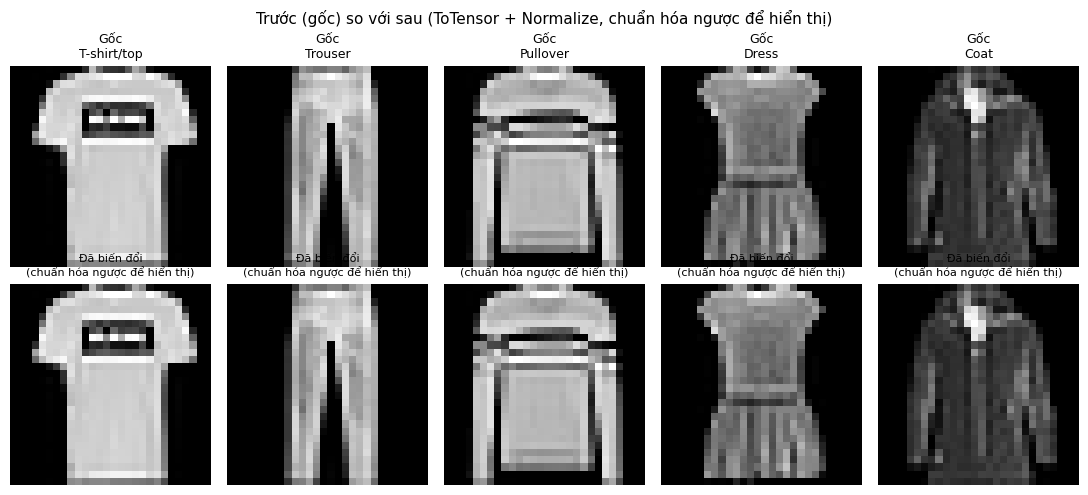

In [10]:
num_show = 5
demo_indices = ordered_indices[:num_show]

fig, axes = plt.subplots(2, num_show, figsize=(num_show * 2.2, 5))
for col, idx in enumerate(demo_indices):
    pil_img, label = raw_train[idx]
    raw_arr = np.array(pil_img)

    normalized_tensor = eval_transform(pil_img)
    denorm_img = (normalized_tensor * FASHION_MNIST_STD[0] + FASHION_MNIST_MEAN[0]).squeeze().numpy()

    axes[0, col].imshow(raw_arr, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"Gốc\n{CLASS_NAMES[label]}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(denorm_img, cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title("Đã biến đổi\n(chuẩn hóa ngược để hiển thị)", fontsize=8)
    axes[1, col].axis("off")

fig.suptitle("Trước (gốc) so với sau (ToTensor + Normalize, chuẩn hóa ngược để hiển thị)", fontsize=11)
fig.tight_layout()
fig.show()


**Nhận xét:** hàng trên (gốc) và hàng dưới (đã biến đổi, sau đó chuẩn hóa ngược) trông
giống hệt nhau về mặt hình ảnh, đúng như kỳ vọng - `ToTensor`/`Normalize` là các phép biến
đổi khả nghịch (invertible), theo từng pixel. Chỉ có *biểu diễn số* đưa vào mô hình thay
đổi; nội dung hình ảnh và nhãn được giữ nguyên hoàn toàn.


## 7. Chiến lược chia tập Train / Validation / Test

```
Tập huấn luyện gốc của FashionMNIST (60,000 ảnh)
        |
        +---- Tập con huấn luyện   (~90%)
        |
        +---- Tập con validation (~10%)

Tập kiểm tra chính thức của FashionMNIST (10,000 ảnh)
        |
        +---- Chỉ dùng để kiểm tra cuối cùng
```

- **Tập kiểm tra (test set)** chính thức không bao giờ được động đến cho tới bước đánh giá
  cuối cùng (`scripts/evaluate.py`) - nó không được dùng để chọn siêu tham số hay kiến trúc
  mô hình.
- **Tập huấn luyện (training set)** chính thức được chia một lần duy nhất, với seed cố định,
  thành tập con huấn luyện và tập con validation. Các chỉ số (indices) kết quả được lưu lại
  (cache) dưới `data/splits/split_seed<seed>.json` và được tái sử dụng giống hệt nhau bởi
  mọi mô hình/thí nghiệm trong lab này (MLP baseline, CNN baseline, CNN experiment) - xem
  phần kiểm tra rò rỉ dữ liệu ở Mục 4.


In [11]:
print(f"File split: {split_path}")
print(f"Seed: {split['seed']}, validation_ratio: {split['validation_ratio']}")
print(f"Kích thước tập con huấn luyện: {len(split['train_indices'])} ({len(split['train_indices']) / len(raw_train):.1%} tập huấn luyện chính thức)")
print(f"Kích thước tập con validation: {len(split['val_indices'])} ({len(split['val_indices']) / len(raw_train):.1%} tập huấn luyện chính thức)")
print(f"Kích thước tập kiểm tra chính thức: {len(raw_test)} (giữ lại riêng, chỉ dùng trong scripts/evaluate.py)")


File split: /Users/huynhnamtruong/Documents/LAB1_Deep_Learning/lab01_fashion_mnist/data/splits/split_seed42.json
Seed: 42, validation_ratio: 0.1
Kích thước tập con huấn luyện: 54000 (90.0% tập huấn luyện chính thức)
Kích thước tập con validation: 6000 (10.0% tập huấn luyện chính thức)
Kích thước tập kiểm tra chính thức: 10000 (giữ lại riêng, chỉ dùng trong scripts/evaluate.py)


**Nhận xét:** tập split này được tạo một lần và lưu lại trên đĩa
(`src/dataset.get_or_create_split`), sau đó được tái sử dụng bởi mọi lần chạy chính thức,
vì vậy mọi số liệu validation được báo cáo giữa MLP/CNN/các thí nghiệm trong notebook
`02_training_and_comparison.ipynb` đều có thể so sánh trực tiếp với nhau.

## 8. Khả năng tái lập (Reproducibility)

- `src/seed.py::set_seed` đặt seed cho `random` của Python, `numpy`, và `torch` (CPU + CUDA)
  ngay từ đầu mỗi lần chạy, vì vậy cùng một config sẽ tạo ra cùng một cách khởi tạo trọng số
  và cùng một thứ tự batch.
- Bản thân tập split train/validation được cố định độc lập thông qua
  `data/splits/split_seed42.json` và được tái sử dụng bởi mọi lần chạy chính thức (xem Mục 7).
- Kết hợp lại, hai cơ chế này đảm bảo bất kỳ lần chạy nào trong `runs/` cũng có thể được tái
  lập từ file `config.yaml` đã lưu của nó.


## 9. Tăng cường dữ liệu (chỉ mang tính minh họa - không dùng trong các lần chạy chính thức)

Không có lần chạy chính thức nào trong ba lần chạy của lab này (`mlp_baseline`,
`cnn_baseline`, `cnn_experiment`) sử dụng tăng cường dữ liệu (data augmentation) - yếu tố
duy nhất được thay đổi trong `cnn_experiment` là dropout (0.3 -> 0.5), không phải tăng
cường dữ liệu, vì vậy tăng cường dữ liệu **không** phải là một phần của bất kỳ kết quả nào
được báo cáo.

`src/dataset.build_transforms(augmentation=True)` có hỗ trợ tăng cường dữ liệu
(`RandomHorizontalFlip` + `RandomCrop(28, padding=4)`, chỉ áp dụng cho tập huấn luyện -
các phép biến đổi cho validation/test không bao giờ bao gồm nó). Ô lệnh bên dưới minh họa
nó trông như thế nào, chỉ nhằm mục đích minh họa/hiểu rõ hơn.


/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_6639/2674057898.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


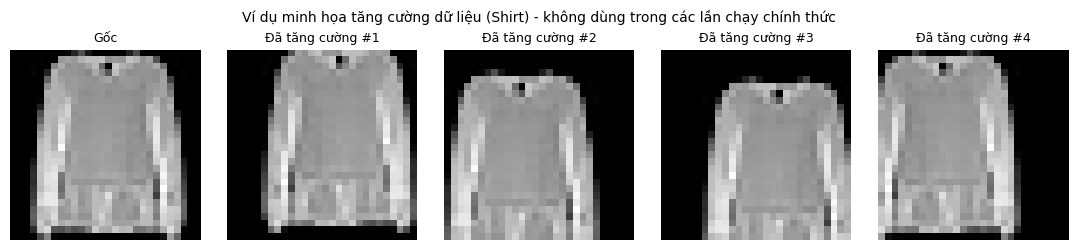

In [12]:
aug_train_transform, _ = build_transforms(augmentation=True)

demo_idx = ordered_indices[6]  # lớp 6 = Shirt, liên quan đến cặp nhầm lẫn lớn nhất sau này
pil_img, label = raw_train[demo_idx]
raw_arr = np.array(pil_img)

fig, axes = plt.subplots(1, 5, figsize=(11, 2.5))
axes[0].imshow(raw_arr, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Gốc", fontsize=9)
axes[0].axis("off")

for i in range(1, 5):
    augmented_tensor = aug_train_transform(pil_img)
    denorm_img = (augmented_tensor * FASHION_MNIST_STD[0] + FASHION_MNIST_MEAN[0]).squeeze().numpy()
    axes[i].imshow(denorm_img, cmap="gray", vmin=0, vmax=1)
    axes[i].set_title(f"Đã tăng cường #{i}", fontsize=9)
    axes[i].axis("off")

fig.suptitle(f"Ví dụ minh họa tăng cường dữ liệu ({CLASS_NAMES[label]}) - không dùng trong các lần chạy chính thức", fontsize=10)
fig.tight_layout()
fig.show()


**Thảo luận - vì sao các phép tăng cường này hợp lý với FashionMNIST:** lật ngang (horizontal
flip) là hợp lý với hầu hết các lớp vì các loại trang phục (áo sơ mi, áo len, áo khoác, váy)
đều có tính đối xứng trái-phải tương đối; crop ngẫu nhiên với padding mô phỏng sự biến thiên
nhỏ về vị trí/khung hình, một nguồn biến thiên thực tế hợp lý trong ảnh sản phẩm. Một lưu ý:
với các lớp có hướng trái-phải đặc trưng (ví dụ một chiếc Sandal hay Ankle boot chụp nghiêng),
việc lật ảnh ít hợp lý hơn rõ ràng - nhưng vì ảnh FashionMNIST đã được căn giữa, độ phân giải
thấp, hình dáng silhouette đơn giản, đây chỉ là một mối lo nhỏ. Vì tăng cường dữ liệu **không**
phải là yếu tố được kiểm định trong `cnn_experiment` của lab này (dropout mới là yếu tố đó),
nó chỉ được trình bày ở đây để hiểu rõ hơn và không ảnh hưởng đến bất kỳ kết quả nào được
báo cáo.
